In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelBinarizer,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\thall\PycharmProjects\uwgb-comp-sci-464-group-project
['.git', '.gitignore', '.idea', '.venv', 'allstate_feature_analysis.ipynb', 'CODEOWNERS', 'data_sources', 'docs', 'examples', 'feature_importance.ipynb', 'README.md', 'requirements.txt', 'venv']


In [3]:
base_dir = "./data_sources/prosafe_dataset"
policy_from_2011_to_2014 = pd.read_csv(f"{base_dir}/policy_from_2011_to_2014.csv")
policy_from_2014_to_2018 = pd.read_csv(f"{base_dir}/policy_from_2014_to_2018.csv")

In [4]:
# Step 1: Choose Input Feature(s) and Corresponding Predicted Output Feature

target_col = "PREMIUM"

y = policy_from_2011_to_2014['PREMIUM']
X = policy_from_2011_to_2014.drop(columns=['PREMIUM'])

In [5]:
# 0. DROP features with >50% missing values (and CCM_TON you decided to drop)
X = X.drop(columns=['CCM_TON', 'CARRYING_CAPACITY', 'CLAIM_PAID'])

# Drop rows where target PREMIUM (y) is NaN
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# Fix EFFECTIVE_YR
X['EFFECTIVE_YR'] = pd.to_numeric(X['EFFECTIVE_YR'], errors='coerce')
X['EFFECTIVE_YR'] = X['EFFECTIVE_YR'].fillna(X['EFFECTIVE_YR'].median())

# Fix a few other numeric columns with small NaN counts
X['SEATS_NUM'] = X['SEATS_NUM'].fillna(X['SEATS_NUM'].median())
X['PROD_YEAR'] = X['PROD_YEAR'].fillna(X['PROD_YEAR'].median())

# Date columns → ordinals
date_cols = ["INSR_BEGIN", "INSR_END"]
for col in date_cols:
    X[col] = pd.to_datetime(X[col], format='%d-%b-%y', errors='coerce')
    X[col] = X[col].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# Fill any remaining numeric NaNs (e.g., from bad dates)
X = X.fillna(X.median(numeric_only=True))

# One-hot encode categoricals
cat_cols = ['TYPE_VEHICLE', 'MAKE', 'USAGE']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Final sanity check


# 2. Split AFTER preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (234823, 487)
X_test shape: (58706, 487)


In [6]:
# 1. See which columns are still object (string) type
obj_cols = X_train.select_dtypes(include=['object']).columns
print("Object columns:", list(obj_cols))

Object columns: []


In [7]:
# TRAIN

rf = RandomForestRegressor(
    n_estimators=50,    # way fewer trees than 300
    max_depth=15,       # cap tree depth
    max_features='sqrt',# try fewer features per split
    n_jobs=-1,          # all cores
    random_state=42
)

rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("R²:", r2_score(y_test, y_pred))

R²: 0.6567755199362557


In [8]:
# obtain importances for  Random Forest
importances_rf = rf.feature_importances_

feature_importance_rf = pd.Series(importances_rf, index=X.columns)

print("Random Forest Feature Importance: ")
print(feature_importance_rf.sort_values(ascending=False)[0:10])

Random Forest Feature Importance: 
INSURED_VALUE               0.329033
USAGE_General Cartage       0.080506
PROD_YEAR                   0.062248
TYPE_VEHICLE_Truck          0.046097
TYPE_VEHICLE_Motor-cycle    0.044162
SEATS_NUM                   0.043035
MAKE_IVECO                  0.038195
INSR_END                    0.028876
SEX                         0.028175
MAKE_ISUZU                  0.022606
dtype: float64


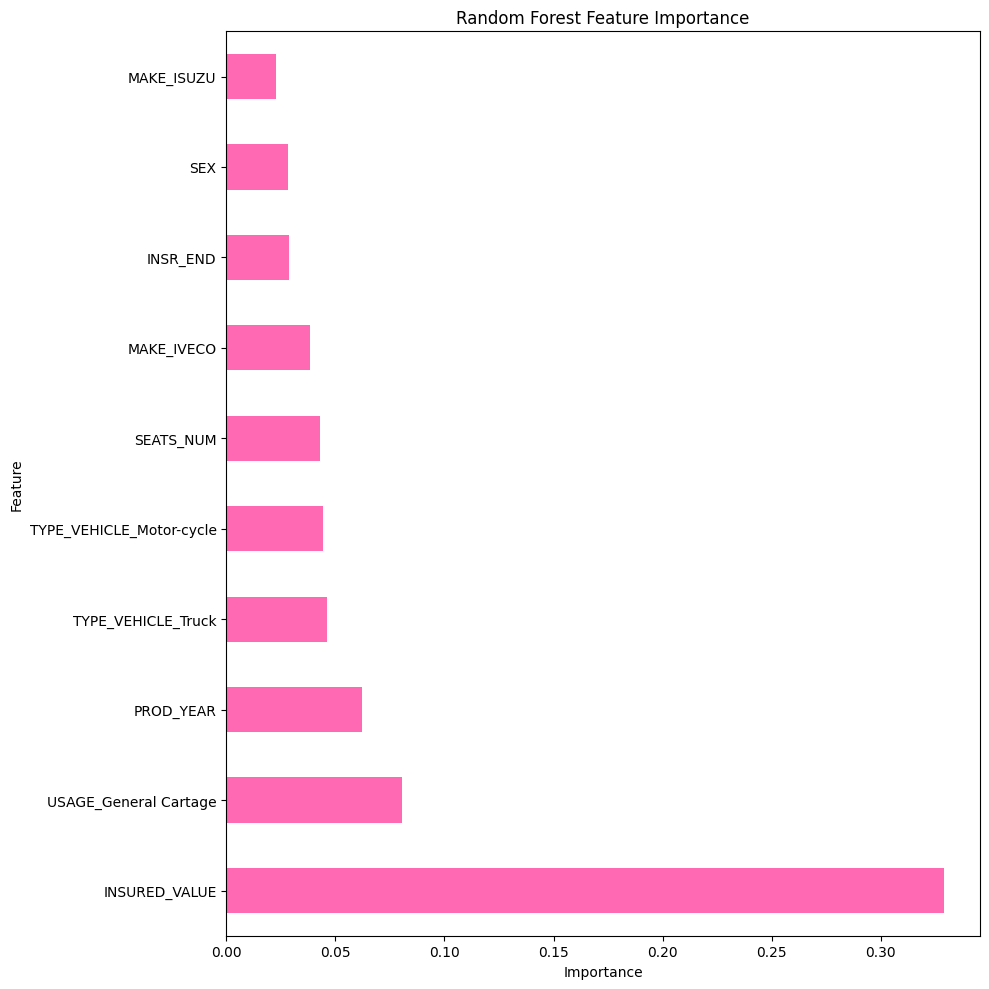

In [9]:
# visualization of the Random Forest importances
plt.figure(figsize=(10, 10))
feature_importance_rf.sort_values(ascending=False)[0:10].plot(kind='barh', color='hotpink')
plt.title("Random Forest Feature Importance")
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [10]:
# Linear Regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred = linear_regression.predict(X_test)

print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE)", mean_absolute_error(y_test, y_pred))

Mean Squared Error (MSE): 31640670.503550265
R^2 Score: 0.604374137489408
Mean Absolute Error (MAE) 3402.4925736458194


In [12]:
# SVR
X_subset = X[0:100]
y_subset = y[0:100]
X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)
svr = SVR(kernel='linear')
svr.fit(X_train, np.ravel(y_train))

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [13]:
y_pred = svr.predict(X_test)

print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE)", mean_absolute_error(y_test, y_pred))

Mean Squared Error (MSE): 4.444712265269687e+25
R^2 Score: -4.723875080179803e+17
Mean Absolute Error (MAE) 6492256440261.575
